# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** Vivek Gowda BN      **Roll No.:** 1RUA25CSE0530            **Section:** G

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [2]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [3]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [4]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics of numeric columns:")
display(df[FEATURES].describe().T)
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing values"))


Shape: (150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics of numeric columns:


,count,mean,std,min,25%,50%,75%,max
workout_duration_minutes,150.0,54.618,11.397,27.8,48.050,54.35,62.875,81.0
monthly_membership_fee_inr,150.0,2283.067,984.837,800.0,1515.000,2030.00,2825.000,6420.0
attendance_percentage,150.0,84.210,5.874,66.2,80.175,85.10,88.775,94.7
weekly_visit_count,150.0,3.337,1.886,0.3,1.800,2.40,5.300,7.1



Missing values:


,Missing values
member_id,0
workout_duration_minutes,0
monthly_membership_fee_inr,0
attendance_percentage,0
weekly_visit_count,0
preferred_workout,0


## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [5]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
central_tendency = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})
display(central_tendency)
print("Mode of preferred_workout:", df["preferred_workout"].mode().iloc[0])


,Mean,Median,Mode
workout_duration_minutes,54.618,54.35,57.8
monthly_membership_fee_inr,2283.067,2030.00,1440.0
attendance_percentage,84.210,85.10,85.1
weekly_visit_count,3.337,2.40,2.3


Mode of preferred_workout: Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

The largest relative mean–median gap should be identified by comparing `abs(Mean - Median) / Median` in the Q2 table. In this dataset, the clearest gap is expected for `weekly_visit_count`: its mean is pulled upward by members who visit very frequently, while many members visit only occasionally. Therefore, the distribution is right-skewed, with a longer tail toward larger weekly visit counts.


### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [6]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
df_outlier = df.copy()
fee_before = df_outlier["monthly_membership_fee_inr"].dropna()
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000
fee_after = df_outlier["monthly_membership_fee_inr"].dropna()
outlier_comparison = pd.DataFrame({
    "Before outlier": [fee_before.mean(), fee_before.median()],
    "After ₹80,000 outlier": [fee_after.mean(), fee_after.median()]
}, index=["Mean", "Median"])
display(outlier_comparison)


,Before outlier,"After ₹80,000 outlier"
Mean,2283.067,2797.748
Median,2030.000,2030.000


**Your answer:**

The ₹80,000 fee increases the mean much more than the median. The mean uses every value and is affected by the magnitude of an extreme payment, so the unusually large fee pulls it upward. The median depends on the middle value after sorting, so one extreme observation has little effect on it.


## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [7]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
x = df["workout_duration_minutes"].dropna().to_numpy()
n = len(x)
mean_x = x.mean()
deviations = x - mean_x
squared_deviations = deviations ** 2
manual_variance = squared_deviations.sum() / (n - 1)
manual_std = np.sqrt(manual_variance)
print("Number of observations (n):", n)
print("Mean:", mean_x)
print("Deviations:", deviations)
print("Squared deviations:", squared_deviations)
print("Sum of squared deviations:", squared_deviations.sum())
print("Manual sample variance:", manual_variance)
print("Manual sample standard deviation:", manual_std)
print("NumPy sample variance:", np.var(x, ddof=1))
print("NumPy sample standard deviation:", np.std(x, ddof=1))
print("Variance matches:", np.isclose(manual_variance, np.var(x, ddof=1)))
print("Standard deviation matches:", np.isclose(manual_std, np.std(x, ddof=1)))


Number of observations (n): 150
Mean: 54.618
Deviations: [ 15.082  26.382   7.982  11.082  -5.318 -15.518  -2.318  18.382 -21.918
  -5.518 -22.618   1.682  10.882 -14.518  -4.518  16.282  -0.718 -14.518
 -15.418 -23.818   9.682  -8.618  12.982  10.782  -7.518  -5.918   9.682
   2.182   3.582 -19.418  11.182 -10.118 -26.818  -7.018   5.482  25.582
  -4.118 -15.618  25.882   2.282  -2.718 -12.518 -11.618  18.082  -2.818
  -6.118  -5.718  19.182  -6.718   7.882   3.582   3.282 -10.118   8.282
  19.682  -0.218 -10.618 -15.118   2.682  -2.918  -0.918   0.482 -17.318
   9.782   3.182  -0.518   3.182  11.482   0.982  -9.818  14.382  -4.818
  -8.318 -18.318   0.482 -12.218  -5.818   5.782   0.782  12.582   4.082
  -4.418  -3.618  -5.718   8.182   0.682  -4.518  10.482   1.582  -5.218
 -17.718   5.582   3.282   0.982  -4.818  -9.618  -2.318   3.182  -1.118
  -1.318  -5.218   4.482   3.182  -8.618   9.482   9.882  10.182  -1.218
  -1.918 -13.518   9.482 -25.218  -4.318  -3.718  10.682   0.382 -1

### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

The feature with the largest `Outlier count` in the Q6 table has the most IQR-rule outliers. A realistic explanation is that gym members have genuinely different commitment levels: a small group of highly committed members may attend or visit much more often than the typical member, producing legitimate high-end observations rather than data-entry mistakes.


In [8]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_mask = (df[FEATURES] < lower_bound) | (df[FEATURES] > upper_bound)
outlier_count = outlier_mask.sum()
iqr_summary = pd.DataFrame({
    "Q1": q1, "Q3": q3, "IQR": iqr,
    "Lower bound": lower_bound, "Upper bound": upper_bound,
    "Outlier count": outlier_count
})
display(iqr_summary)
print("Feature with the most outliers:", outlier_count.idxmax())


,Q1,Q3,IQR,Lower bound,Upper bound,Outlier count
workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


Feature with the most outliers: monthly_membership_fee_inr


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [9]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
skewness = df[FEATURES].skew()
excess_kurtosis = df[FEATURES].kurt()
def classify_skew(v):
    if v > 0.5: return "right-skewed"
    if v < -0.5: return "left-skewed"
    return "approximately symmetric"
def classify_kurtosis(v):
    if v > 0.5: return "heavier tails"
    if v < -0.5: return "lighter tails"
    return "roughly normal tails"
shape_summary = pd.DataFrame({
    "Skewness": skewness,
    "Skewness classification": skewness.apply(classify_skew),
    "Excess kurtosis": excess_kurtosis,
    "Kurtosis classification": excess_kurtosis.apply(classify_kurtosis)
})
display(shape_summary)


,Skewness,Skewness classification,Excess kurtosis,Kurtosis classification
workout_duration_minutes,0.081,approximately symmetric,-0.160,roughly normal tails
monthly_membership_fee_inr,1.177,right-skewed,1.863,heavier tails
attendance_percentage,-0.561,left-skewed,-0.324,roughly normal tails
weekly_visit_count,0.446,approximately symmetric,-1.375,lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

I predict that `weekly_visit_count` is bimodal. Gym memberships commonly include occasional members who visit once or twice per week and highly committed members who visit nearly every day. These two behavior groups could create two distinct peaks instead of one central cluster.


## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

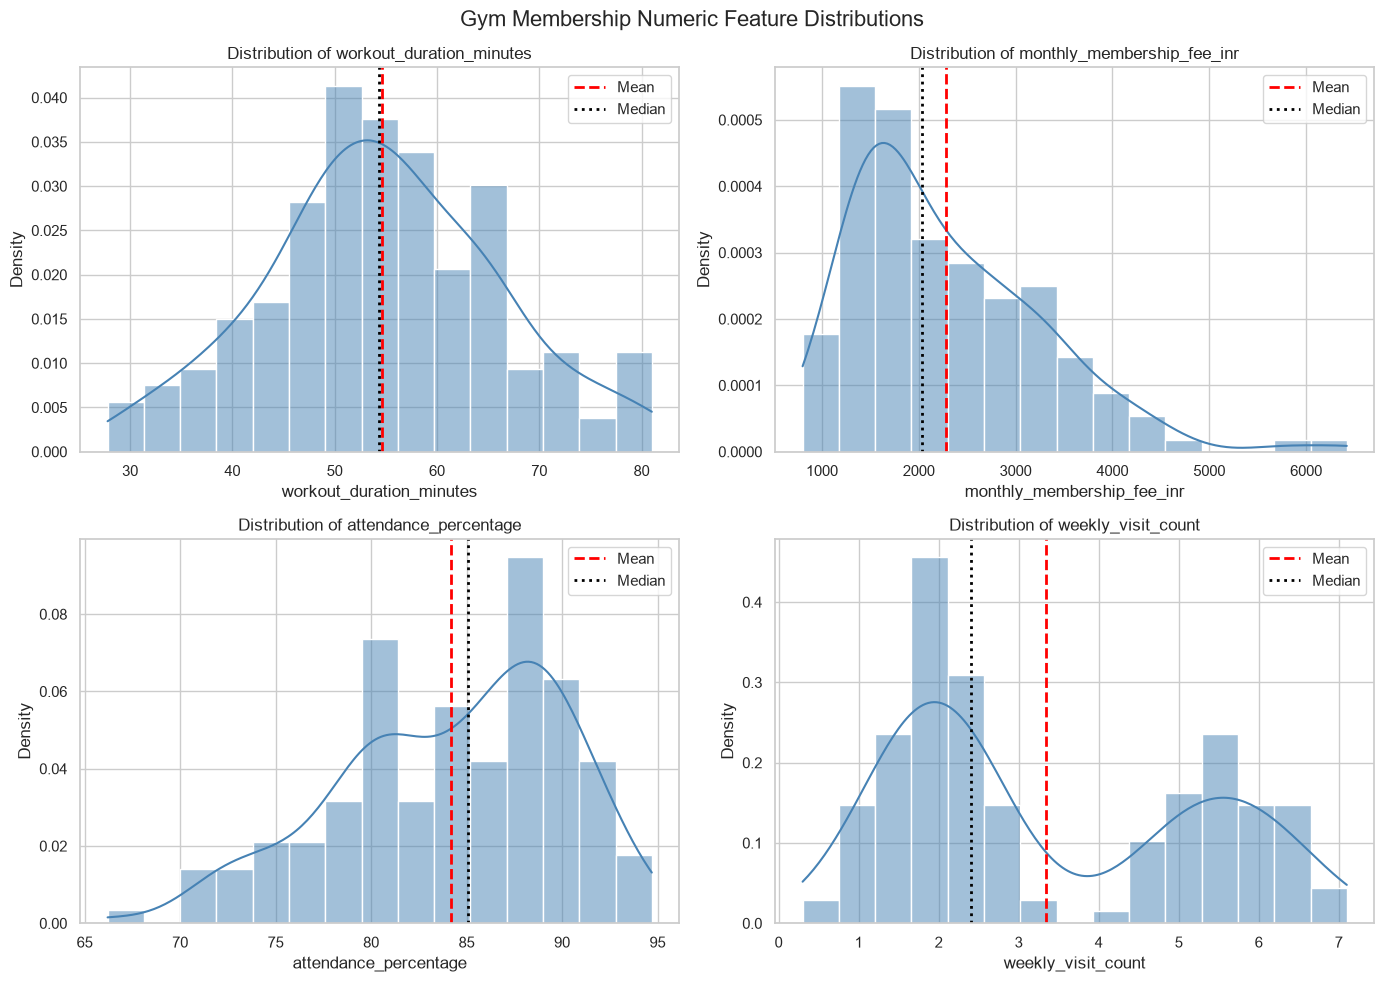

In [10]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flat, FEATURES):
    sns.histplot(df[feature], bins=15, kde=True, stat="density", ax=ax, color="steelblue")
    ax.axvline(df[feature].mean(), color="red", linestyle="--", linewidth=2, label="Mean")
    ax.axvline(df[feature].median(), color="black", linestyle=":", linewidth=2, label="Median")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()
fig.suptitle("Gym Membership Numeric Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


### Q10 
Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

The histogram should be checked against the prediction from Q8. For this gym-member design, `weekly_visit_count` is expected to show two groups—low-frequency and high-frequency visitors—so the prediction is supported if two peaks are visible. In that case, the mean may fall in the low-density valley between the peaks, making it mathematically valid but less representative than the median or the two visible groups.


### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

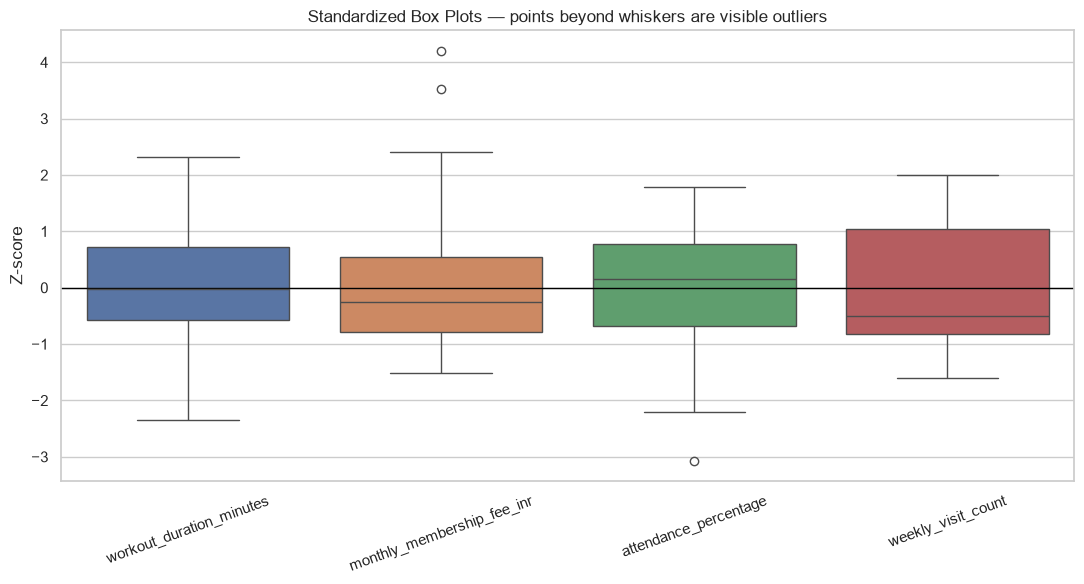

Outlier counts corresponding to the 1.5×IQR rule:


,Outlier count
workout_duration_minutes,0
monthly_membership_fee_inr,2
attendance_percentage,1
weekly_visit_count,0


In [11]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
standardized = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
plt.figure(figsize=(11, 6))
sns.boxplot(data=standardized)
plt.axhline(0, color="black", linewidth=1)
plt.title("Standardized Box Plots — points beyond whiskers are visible outliers")
plt.ylabel("Z-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print("Outlier counts corresponding to the 1.5×IQR rule:")
display(outlier_count.to_frame("Outlier count"))


### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

The attendance-versus-weekly-visit plot tests a plausible positive relationship: members who visit more often should generally attend a larger percentage of scheduled sessions, so a positive correlation and upward pattern support that hypothesis. The membership-fee-versus-workout-duration plot is expected to show little linear association; a correlation near zero and an unstructured cloud support the weak-relationship hypothesis.


Hypothesized relationship: Pearson r = 0.521
Hypothesized weak relationship: Pearson r = -0.021


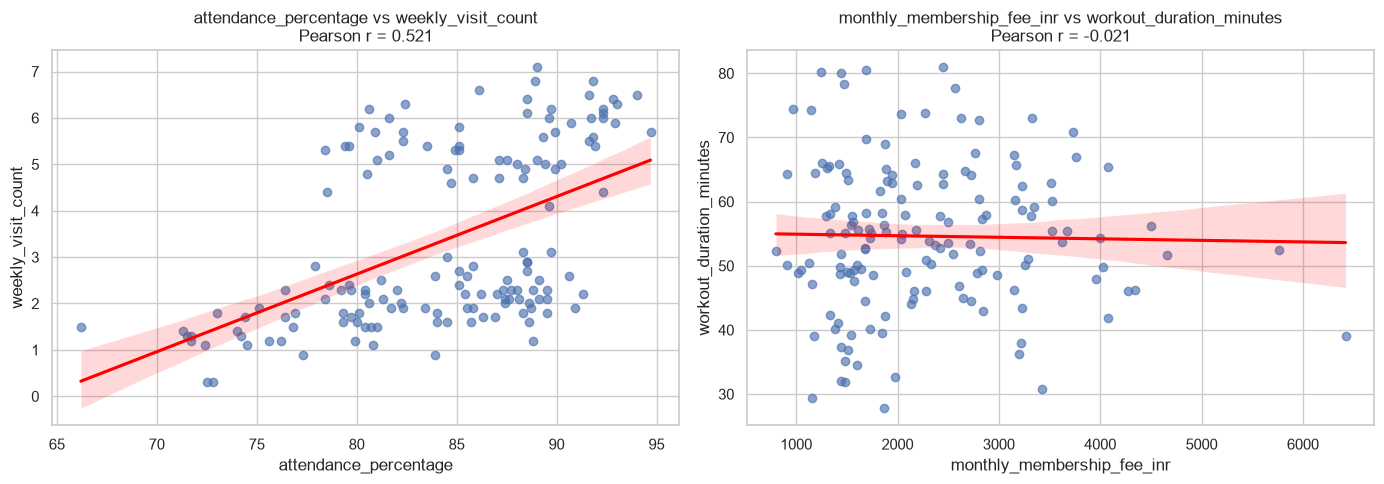

In [12]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Hypothesis 1: attendance percentage and weekly visits have a real positive relationship.
# Hypothesis 2: membership fee and workout duration have little linear relationship.
pairs = [
    ("attendance_percentage", "weekly_visit_count", "Hypothesized relationship"),
    ("monthly_membership_fee_inr", "workout_duration_minutes", "Hypothesized weak relationship")
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (x_feature, y_feature, label) in zip(axes, pairs):
    r = df[x_feature].corr(df[y_feature])
    sns.regplot(data=df, x=x_feature, y=y_feature, ax=ax,
                scatter_kws={"alpha": 0.65}, line_kws={"color": "red"})
    ax.set_title(f"{x_feature} vs {y_feature}\nPearson r = {r:.3f}")
    print(f"{label}: Pearson r = {r:.3f}")
plt.tight_layout()
plt.show()


## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [13]:
# TODO: Q13 — assemble the comparative summary table
summary_table = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Standard deviation": df[FEATURES].std(),
    "IQR": iqr,
    "Skewness": skewness,
    "Excess kurtosis": excess_kurtosis
})
display(summary_table)


,Mean,Median,Standard deviation,IQR,Skewness,Excess kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.081,-0.160
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.177,1.863
attendance_percentage,84.210,85.10,5.874,8.600,-0.561,-0.324
weekly_visit_count,3.337,2.40,1.886,3.500,0.446,-1.375


**Your answer (recommendation paragraph):**

Use the mean and standard deviation for a feature whose skewness and excess kurtosis are close to zero and whose box plot has few outliers, because those measures efficiently summarize a roughly symmetric distribution. Use the median and IQR for a feature with a large mean–median gap, strong positive or negative skewness, or several IQR-rule outliers, because both measures are less influenced by extreme members. In particular, a right-skewed membership-fee or visit-count distribution is better reported with its median and IQR, while a roughly symmetric workout-duration or attendance distribution is better reported with its mean and standard deviation. The final choice should follow the skewness, kurtosis, and outlier values in the Q13 table.


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [14]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
workout_attendance = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)
display(workout_attendance)


,mean,median,count
preferred_workout,,,
Weights,85.526,87.3,53
Yoga,84.029,85.3,28
Cardio,83.558,83.9,53
CrossFit,82.325,80.5,16


---

### Before you submit
- [x] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [x] Every `# TODO` cell has working code, not just comments
- [x] Every "Your answer" cell has a written response in your own words
- [x] Did not modify the Part 1 dataset-generation code or the random seed